# 01 – Data Collection & Exploratory Data Analysis
**Project**: Spotify Music Recommender & Analysis  
**Author**: S33mi  
**Goal**: Load the Spotify tracks dataset, clean it, and perform thorough EDA to understand audio features, genres, and popularity patterns.  
Insights from this notebook will guide feature engineering and the recommender system.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 50)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load the Dataset

Download the dataset from:  
https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset  
Place `dataset.csv` in a `data/` folder (or update the path below).
OR you can use kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)

100%|██████████| 8.17M/8.17M [00:00<00:00, 52.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/maharshipandya/-spotify-tracks-dataset/versions/1


In [8]:

# Update the path if needed
#DATA_PATH = "data/dataset.csv"

#df = pd.read_csv(DATA_PATH)
#print(f"Dataset shape: {df.shape}")
#df.head()
# --------------------
#path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
df = pd.read_csv(f"{path}/dataset.csv")   # ← change filename if different
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic



## 3. Basic Information & Data Quality


In [9]:
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n=== Duplicate Rows ===")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\n=== Unique Values (selected columns) ===")
print(f"Unique track_ids : {df['track_id'].nunique()}")
print(f"Unique artists   : {df['artists'].nunique()}")
print(f"Unique genres    : {df['track_genre'].nunique()}")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16 


### Quick Cleaning
- Drop exact duplicates
- Remove rows with missing critical values (if any)
- Convert duration to minutes for readability


In [10]:
# Drop duplicates
df = df.drop_duplicates(subset=["track_id"]).reset_index(drop=True)

# Duration in minutes
df["duration_min"] = df["duration_ms"] / 60000

# Optional: drop the original Unnamed index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (89741, 21)



## 4. Audio Feature Descriptions

These are the core features we will use for recommendation:

| Feature            | Description                                      | Range      |
|--------------------|--------------------------------------------------|------------|
| danceability       | How suitable a track is for dancing              | 0.0 – 1.0  |
| energy             | Intensity and activity                           | 0.0 – 1.0  |
| key                | Musical key (0 = C, 1 = C♯/D♭, …)                | 0 – 11     |
| loudness           | Overall loudness in dB                           | typically -60 to 0 |
| mode               | Major (1) or Minor (0)                           | 0 or 1     |
| speechiness        | Presence of spoken words                         | 0.0 – 1.0  |
| acousticness       | Confidence the track is acoustic                 | 0.0 – 1.0  |
| instrumentalness   | Predicts whether a track contains no vocals      | 0.0 – 1.0  |
| liveness           | Presence of an audience                          | 0.0 – 1.0  |
| valence            | Musical positiveness (happy → sad)               | 0.0 – 1.0  |
| tempo              | Estimated tempo in BPM                           | usually 50–200 |
| duration_ms        | Track length in milliseconds                     | –          |
| popularity         | Spotify popularity score                         | 0 – 100    |



## 5. Univariate Analysis – Distributions of Audio Features


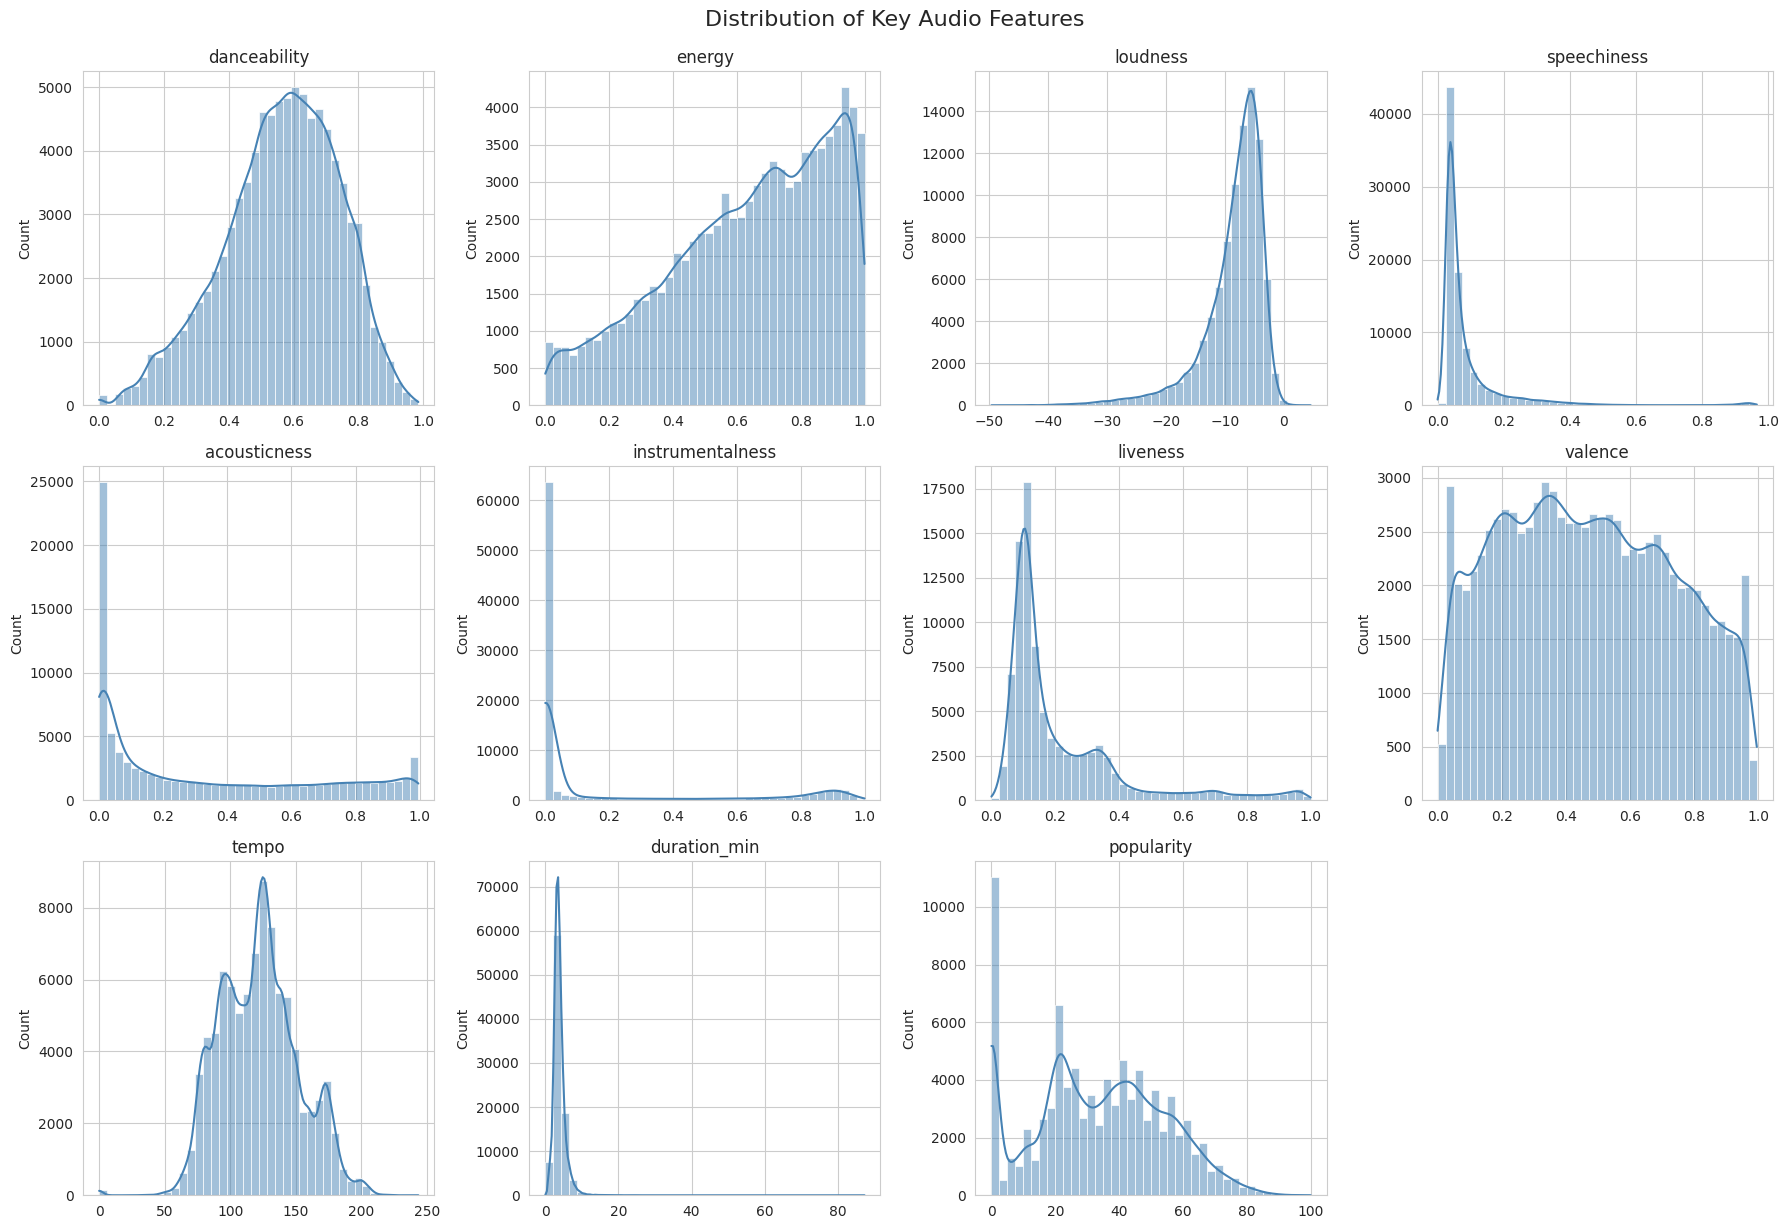

In [11]:

audio_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_min", "popularity"
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(audio_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue", bins=40)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("")

# Hide unused subplot
if len(audio_features) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.suptitle("Distribution of Key Audio Features", y=1.02, fontsize=16)
plt.show()


## 6. Correlation Analysis

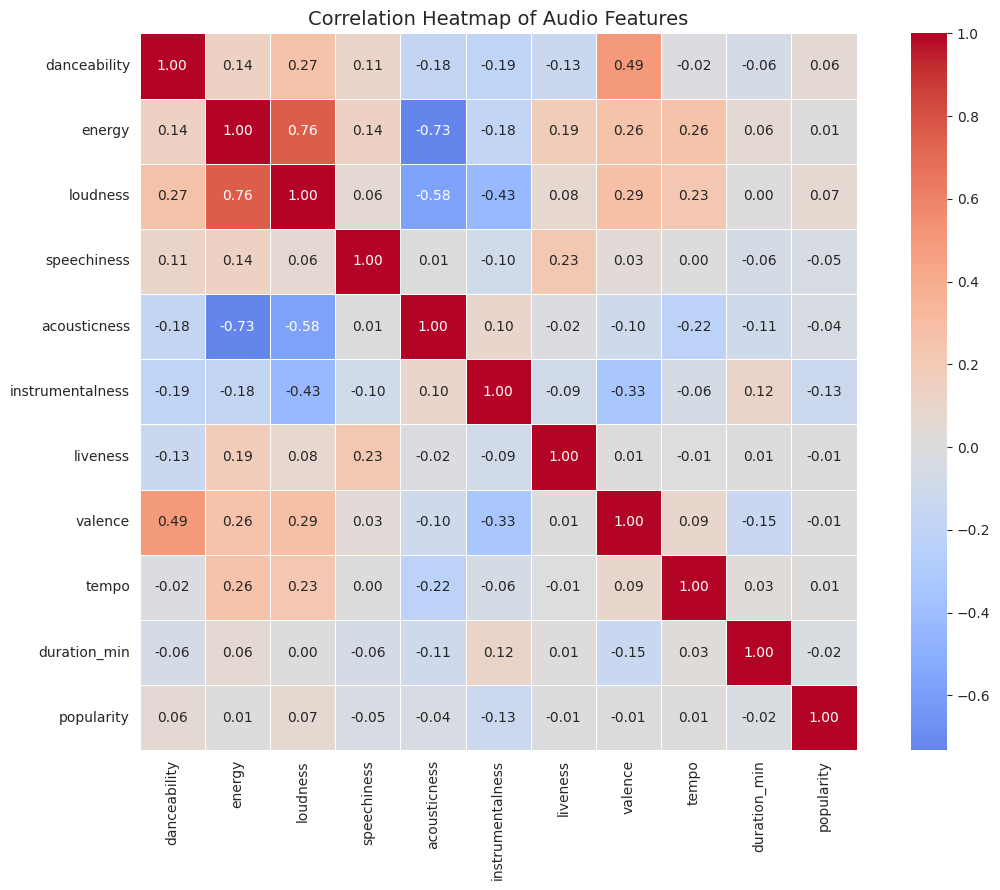

In [12]:
corr_matrix = df[audio_features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Audio Features", fontsize=14)
plt.tight_layout()
plt.show()


**Quick observations** (update after running):
- Energy and loudness are usually strongly positively correlated.
- Acousticness tends to be negatively correlated with energy and loudness.
- Valence (positiveness) often shows moderate positive correlation with danceability.


# ## 7. Genre Analysis


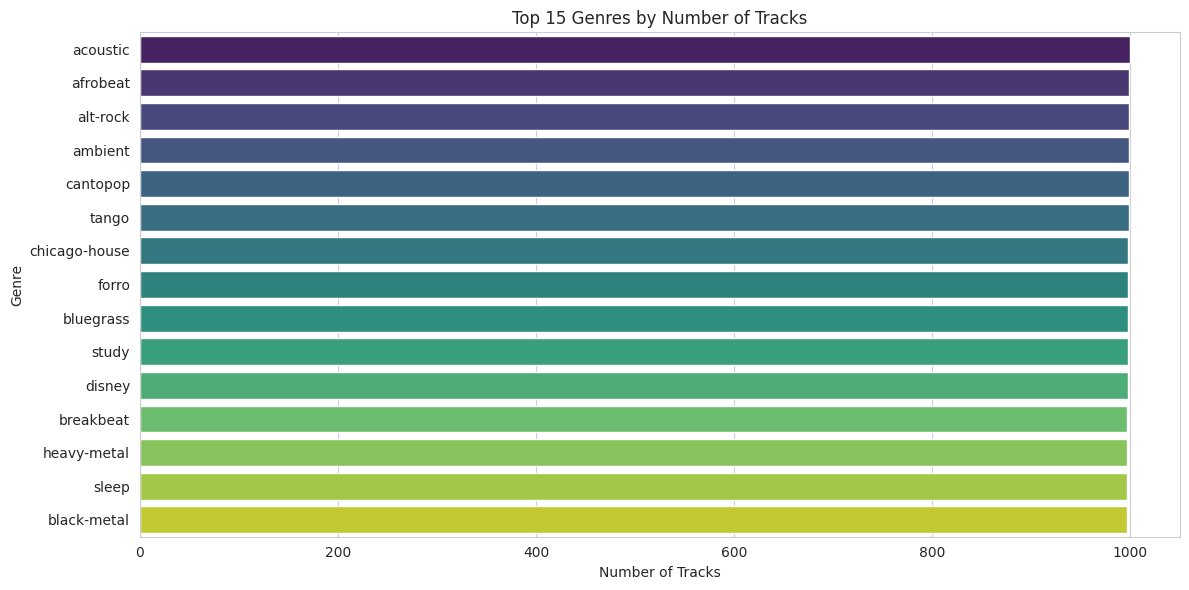

In [13]:
# Top 15 genres by number of tracks
top_genres = df["track_genre"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
plt.title("Top 15 Genres by Number of Tracks")
plt.xlabel("Number of Tracks")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

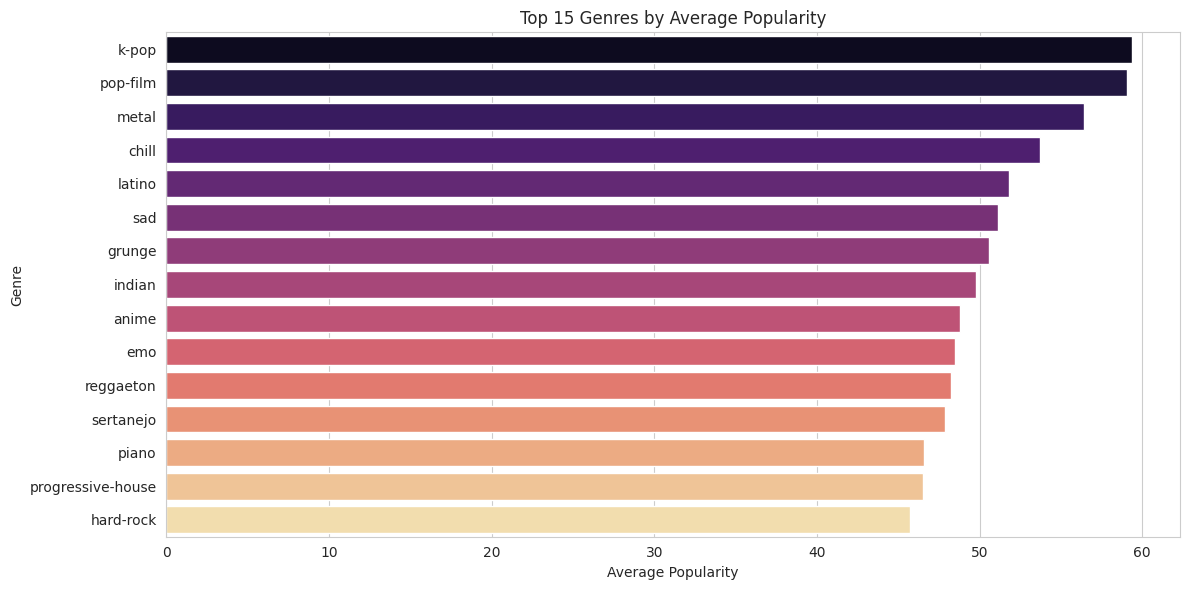

In [14]:

# Average popularity by genre (top 15)
genre_popularity = (
    df.groupby("track_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_popularity.values, y=genre_popularity.index, palette="magma")
plt.title("Top 15 Genres by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

## 8. Popularity Insights


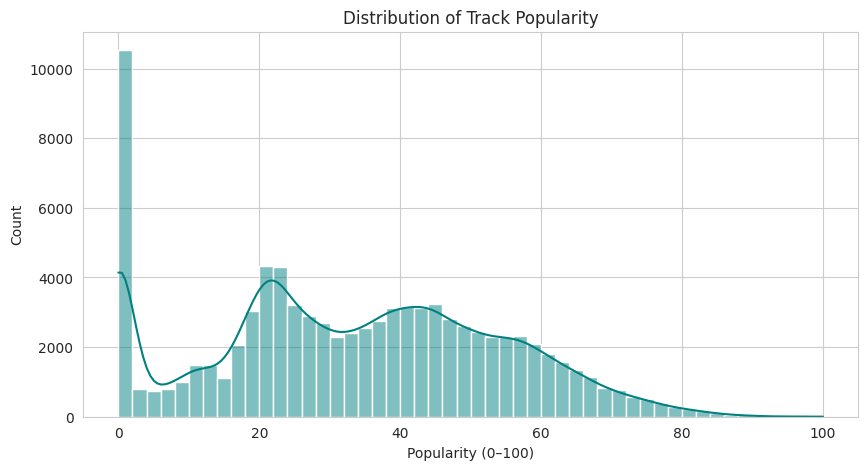

Top 10 most popular tracks:


,track_name,artists,track_genre,popularity,danceability,energy,valence
18906,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100,0.714,0.472,0.238
45781,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99,0.621,0.782,0.550
18913,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98,0.561,0.965,0.304
57109,La Bachata,Manuel Turizo,latin,98,0.835,0.679,0.850
57111,Me Porto Bonito,Bad Bunny;Chencho Corleone,latin,97,0.911,0.712,0.425
57112,Tití Me Preguntó,Bad Bunny,latin,97,0.650,0.715,0.187
18905,Under The Influence,Chris Brown,dance,96,0.733,0.690,0.310
57291,Efecto,Bad Bunny,latin,96,0.801,0.475,0.234
66009,I Ain't Worried,OneRepublic,piano,96,0.704,0.797,0.825
57250,Ojitos Lindos,Bad Bunny;Bomba Estéreo,latin,95,0.647,0.686,0.268


In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(df["popularity"], bins=50, kde=True, color="teal")
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity (0–100)")
plt.show()

# High popularity tracks
print("Top 10 most popular tracks:")
display(
    df.nlargest(10, "popularity")[
        ["track_name", "artists", "track_genre", "popularity", "danceability", "energy", "valence"]
    ]
)


## 9. Feature Relationships with Popularity

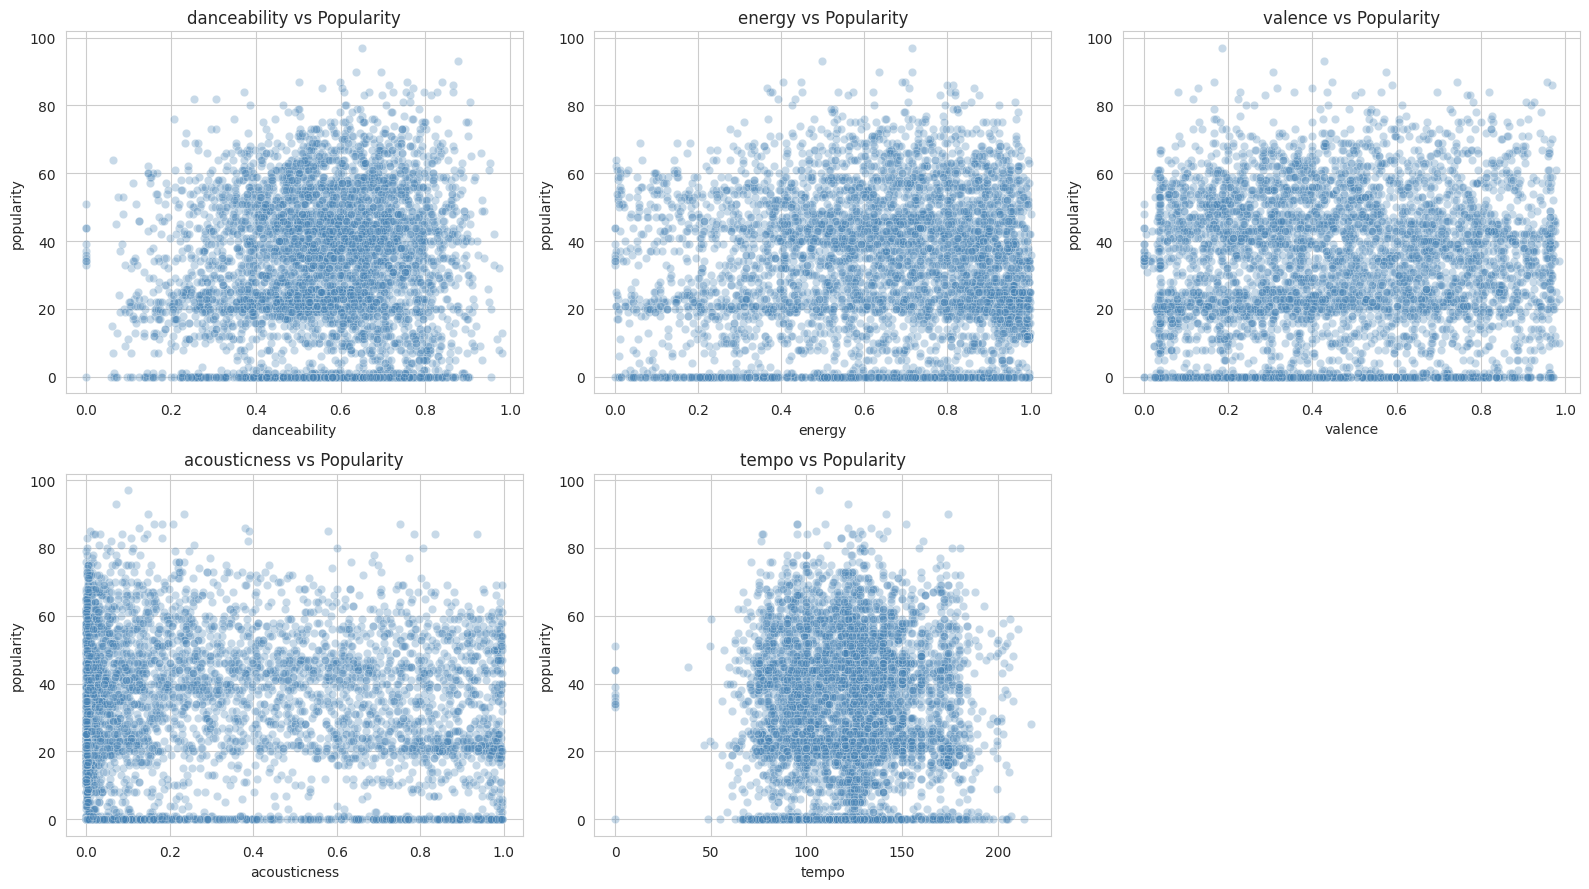

In [16]:
# Scatter plots of selected features vs popularity
selected = ["danceability", "energy", "valence", "acousticness", "tempo"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(selected):
    sns.scatterplot(
        data=df.sample(5000, random_state=42),  # sample for speed
        x=col,
        y="popularity",
        alpha=0.3,
        ax=axes[i],
        color="steelblue"
    )
    axes[i].set_title(f"{col} vs Popularity")

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Summary of Key Insights
  
 - Dataset size after cleaning: **(89741, 21)** tracks
 - Most common genres: **k-pop**
 - Features with strongest correlation to popularity: **danceability and loudness**
 - Notable patterns (e.g., high-energy tracks, valence distribution, etc.):
    - Energy and loudness are usually strongly positively correlated
    - Acousticness tends to be negatively correlated with energy and loudness.
    - Valence (positiveness) often shows moderate positive correlation with danceability.
    - Most of avaiable tracks are very unpopuler or have a low play count.

 These insights will guide:
 - Feature selection for the recommender
 - Scaling strategy
 - Clustering approach in later notebooks

## Next Steps

→ `02_feature_engineering.ipynb`  
- Scale numerical features  
- Optional encoding of key / mode / genre  
- Create a clean feature matrix for similarity calculations